In [1]:
import numpy as np
import time
import math
import matplotlib.pyplot as plt

import torch

torch.set_default_dtype(torch.float64)

# Dimension

In [2]:
# Set the dimension
d = 5

# Random Walk

In [3]:
def random_walk_to_boundary(start):
    batch_size = start.shape[0]
    current = torch.clone(start)

    max_steps = 10000 # Safety break for long walks
    step_count = 0

    while step_count < max_steps:
        norms = torch.linalg.norm(current, dim=1)
        # todo: only update norms < 1, this info is already in the flags
        flags = norms >= 1.0

        # Stop if all walks are outside ball
        if flags.all(): break

        # Random step
        ## Batch of normal random vectors
        normal = torch.normal(0, 1, size=(batch_size, d), dtype=torch.float64)
        ## Calculate size of random step
        delta = (1-norms)/2
        ## Batch of scalars =delta if corresponding vector is inside ball and =0 otherwise
        a = delta * (~flags).int()
        ## Resize or null batch of normal vectors for the random step
        current += a.unsqueeze(1) * normal

    if step_count == max_steps:
        raise Exception("Walk did not hit boundary")
        # todo: Replace with projection (?)

    # Project to boundary (correct when step_count < max_steps because norms was updated)
    current = (1/norms).unsqueeze(1) * current

    return current

# Generate Samples in Sphere

In [4]:
def generate_samples(size):
    """ Returns a *tensor* of vectors with shape (size, d) """

    normal = torch.normal(0, 1, size=(size, d))
    norms = torch.linalg.norm(normal, dim=1)
    directions = (1/norms).unsqueeze(1) * normal

    radius = torch.pow(torch.rand(size), 1/d)

    return radius.unsqueeze(1) * directions

# Boundary Functions

In [5]:
# Square of first variable
def square_of_x1(x):
    return torch.square(x[:, 0]).unsqueeze(1)

def square_of_x1_analytic(x):
    return x[:, 0]**2 - (1/d) * x.square().sum(dim=1) + (1/d)

# Harmonic quadratic polynomial in first 2 variables
def har_quadratic(x):
    x1 = x[:, 0]
    x2 = x[:, 1]
    z = x1**2 - x2**2
    return z.unsqueeze(1)

def har_quadratic_analytic(x):
    return har_quadratic(x).squeeze(1)

# Quadratic polynomial in first 2 variables
# but in different scales
def har_quadratic_unbalanced(x):
    x1 = x[:, 0]
    x2 = x[:, 1]
    z = 0.01 * x1 ** 2 + 100 * x2 ** 2 # = (0.1 * x1)**2 + (10 * x2)**2
    return z.unsqueeze(1)

def har_quadratic_unbalanced_analytic(x):
    return 0.01 * x[:, 0]**2 + 100 * x[:, 1]**2 - (100.01/d) * x.square().sum(dim=1) + (100.01/d)

# Harmonic cubic polynomial in first 4 variables
def har_cubic(x):
    x1 = x[:, 0]
    x2 = x[:, 1]
    x3 = x[:, 2]
    x4 = x[:, 3]
    z = x1**3 - x1*x2**2 - x1*x3**2 - x1*x4**2
    return z.unsqueeze(1)

def har_cubic_analytic(x):
    return har_cubic(x).squeeze(1)

# Harmonic quintic polynomial in first 4 variables
def har_quintic(x):
    x1 = x[:, 0]
    x2 = x[:, 1]
    x3 = x[:, 2]
    x4 = x[:, 3]
    z = x1**5 - 10*x1**3*x2**2 + 5*x1*x2**4 + x3**5 - 10*x3**3*x4**2 + 5*x3*x4**4
    return z.unsqueeze(1)

def har_quintic_analytic(x):
    return har_cubic(x).squeeze(1)

## Select Boundary Function

The boundary function is called $\varphi$ ($\texttt{phi}$) and the corresponding analytic solution (if it has a nice expression) is called $\texttt{u\_ analytic}$.

In [6]:
phi = har_quadratic_unbalanced
u_analytic = har_quadratic_unbalanced_analytic

# NN Architecture

In [7]:
N = torch.nn.Sequential(
    torch.nn.Linear(d, 40), torch.nn.Tanh(),
    torch.nn.Linear(40, 40), torch.nn.Tanh(),
    torch.nn.Linear(40, 40), torch.nn.Softplus(),
    torch.nn.Linear(40, 40), torch.nn.Tanh(),
    torch.nn.Linear(40, 40), torch.nn.Softplus(),
    torch.nn.Linear(40, 40), torch.nn.Tanh(),
    torch.nn.Linear(40, 1)
)

# Training Parameters

In [8]:
# Configure the training parameters and optimization algorithm
steps = 20000
training_size = 100000
batch_size = 128
lr = 0.001

optimizer = torch.optim.Adam(N.parameters(), lr=lr)

# Loss Function

In [9]:
def loss(model, x): 
    # x is a batch_size x N tensor
    nn_output = model(x)

    xx = random_walk_to_boundary(x)
    boundary_values_tensor = phi(xx)

    total_loss = torch.square(nn_output - boundary_values_tensor).mean()

    return total_loss

# Training Loop

In [10]:
from tqdm import tqdm # For progress bar

x_all = generate_samples(training_size)

all_epoch_losses = [] # List to store loss at every epoch for graphing
logged_training_losses = [] # List to store loss at specified intervals for printing/saving

pbar = tqdm(range(steps), desc='Training', unit='epochs')
for step in pbar:
    # Select a random batch from x_all
    indices = torch.randint(0, training_size, (batch_size,))
    x = x_all[indices]

    # Optimize
    L = loss(N, x)
    optimizer.zero_grad()
    L.backward()
    optimizer.step()

    # Store loss for every epoch
    all_epoch_losses.append(L.item())

    if step % 500 == 0:
        pbar.set_description(f'Training: Loss = {L.item():.2e}')

Training: Loss = 1.89e+02: 100%|██████| 20000/20000 [04:45<00:00, 70.15epochs/s]


# Numerical Comparison

Compare NN solution with analytic solution if available

In [11]:
# Compute relative error
n_samples = 100 * batch_size

N.eval() # Switch to evaluation mode

with torch.no_grad(): # Disable gradient calculation for testing
    # 1. Generate samples
    x = generate_samples(n_samples)

    # 2. Get predictions and exact values
    u_pred = N(x)
    u_true = u_analytic(x)

    # Ensure shapes match (i.e., both are [N, 1])
    if u_pred.shape != u_true.shape:
        u_true = u_true.reshape(u_pred.shape)

    # 3. Compute Errors
    # Absolute difference vector
    diff = u_pred - u_true

    # L2 Relative Error: ||u_pred - u_true||_2 / ||u_true||_2
    l2_error = torch.norm(diff, p=2) / (torch.norm(u_true, p=2))

print(f"Relative L2 Error: {l2_error.item():.6e}")

Relative L2 Error: 7.484299e-02


# Plot

## Plot along Circle

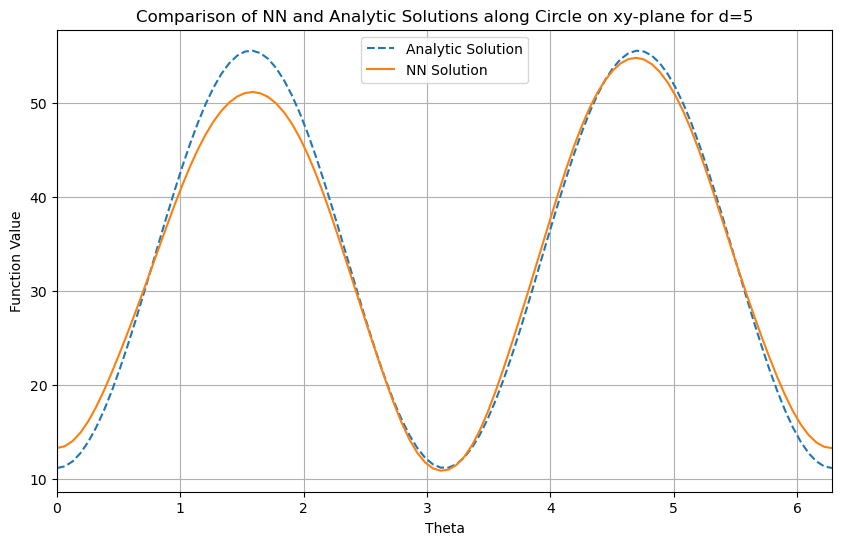

In [12]:
theta_values = np.linspace(0, 2*math.pi, 100)

# Prepare to store the results
nn_output_diagonal = []
analytic_output_diagonal = []

N.eval() # Set the model to evaluation mode
with torch.no_grad(): # Disable gradient calculations
    for theta_val in theta_values:
        point_np = np.zeros(d, dtype=np.float64)

        point_np[0] = (2/3)*math.cos(theta_val)
        point_np[1] = (2/3)*math.sin(theta_val)

        # Get NN solution
        point_tensor = torch.tensor(point_np, dtype=torch.float64).unsqueeze(0) # Add batch dimension
        nn_val = N(point_tensor).item()
        nn_output_diagonal.append(nn_val)

        # Get analytic solution
        analytic_val = u_analytic(point_tensor).item()
        analytic_output_diagonal.append(analytic_val)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(theta_values, analytic_output_diagonal, label='Analytic Solution', linestyle='--')
plt.plot(theta_values, nn_output_diagonal, label='NN Solution')
plt.xlabel('Theta')
plt.ylabel('Function Value')
plt.title(f'Comparison of NN and Analytic Solutions along Circle on xy-plane for d={d}')
plt.legend()
plt.grid(True)

# Adjust plot range
plt.xlim(0, 2*math.pi)
#plt.ylim(-1, 1)

plt.show()

## 3D Plot

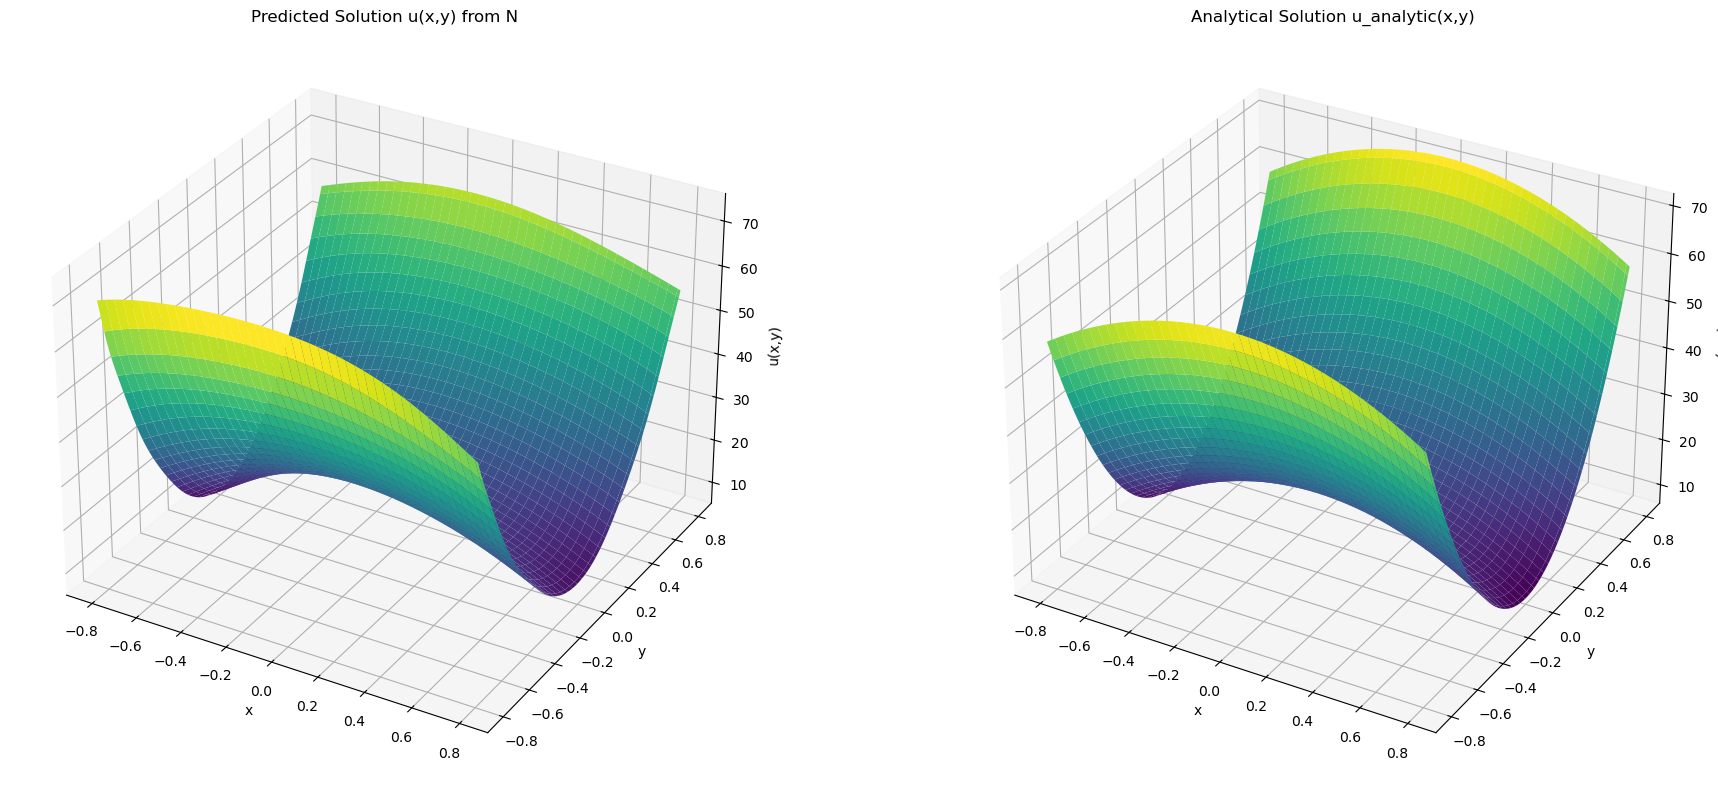

In [13]:
# Plot the predicted solution from N against the exact solution
a, b = -0.8, 0.8 #-1/math.sqrt(2), 1/math.sqrt(2)

mesh = 128

def toNumpy(t):
    return t.detach().cpu().numpy().reshape((mesh,mesh))

# Create a figure with two subplots
fig = plt.figure(figsize=(20, 8)) # Wider figure to accommodate two plots

# Generate meshgrid for the domain
x = torch.linspace(a, b, mesh)
y = torch.linspace(a, b, mesh)
X, Y = torch.meshgrid(x, y, indexing='xy')

# Prepare input for N_sol:
# Chose the first two coordinates from a mesh and set the rest to a=0
# (needs rework): a * torch.ones((coords.shape[0], d-2))
coords = torch.cat((X.reshape(-1, 1), Y.reshape(-1, 1)), 1)
coords = torch.cat((coords, torch.zeros((coords.shape[0], d-2))), 1)

N.eval() # Ensure N_sol is in evaluation mode
with torch.no_grad(): # Disable gradient calculation
    Z_pred_N_sol = N(coords)

Z_analytic = u_analytic(coords)

Z_pred_N_sol_np = toNumpy(Z_pred_N_sol.flatten()) # Flatten and reshape for plotting
Z_analytic_np = toNumpy(Z_analytic.flatten()) # Flatten and reshape for plotting

# --- First Subplot: Predicted Solution from N_sol ---
ax1 = fig.add_subplot(121, projection='3d') # 1 row, 2 columns, 1st plot
ax1.plot_surface(toNumpy(X), toNumpy(Y), Z_pred_N_sol_np,
                cmap='viridis')

ax1.set_title("Predicted Solution u(x,y) from N")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_zlabel("u(x,y)")
#ax1.set_zlim(-2, 2) # Set z-axis limits for better visualization

# --- Second Subplot: Analytical Solution ---
ax2 = fig.add_subplot(122, projection='3d') # 1 row, 2 columns, 2nd plot
ax2.plot_surface(toNumpy(X), toNumpy(Y), Z_analytic_np,
                cmap='viridis')

ax2.set_title("Analytical Solution u_analytic(x,y)")
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_zlabel("u(x,y)")
#ax2.set_zlim(-2, 2) # Set z-axis limits for better visualization

plt.tight_layout() # Adjust layout to prevent overlap
plt.show()